# Te damos la bienvenida a Colab

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df=pd.read_csv('global_energy_consumption.csv')
df.head()

,Country,Year,Total Energy Consumption (TWh),Per Capita Energy Use (kWh),Renewable Energy Share (%),Fossil Fuel Dependency (%),Industrial Energy Use (%),Household Energy Use (%),Carbon Emissions (Million Tons),Energy Price Index (USD/kWh)
0,Canada,2018,9525.38,42301.43,13.70,70.47,45.18,19.96,3766.11,0.12
1,Germany,2020,7922.08,36601.38,33.63,41.95,34.32,22.27,2713.12,0.08
2,Russia,2002,6630.01,41670.20,10.82,39.32,53.66,26.44,885.98,0.26
3,Brazil,2010,8580.19,10969.58,73.24,16.71,30.55,27.60,1144.11,0.47
4,Canada,2006,848.88,32190.85,73.60,74.86,42.39,23.43,842.39,0.48


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          10000 non-null  object 
 1   Year                             10000 non-null  int64  
 2   Total Energy Consumption (TWh)   10000 non-null  float64
 3   Per Capita Energy Use (kWh)      10000 non-null  float64
 4   Renewable Energy Share (%)       10000 non-null  float64
 5   Fossil Fuel Dependency (%)       10000 non-null  float64
 6   Industrial Energy Use (%)        10000 non-null  float64
 7   Household Energy Use (%)         10000 non-null  float64
 8   Carbon Emissions (Million Tons)  10000 non-null  float64
 9   Energy Price Index (USD/kWh)     10000 non-null  float64
dtypes: float64(8), int64(1), object(1)
memory usage: 781.4+ KB


In [4]:
duplicated = df.duplicated().sum()

In [5]:
print(duplicated)

0


In [6]:
df.describe()

,Year,Total Energy Consumption (TWh),Per Capita Energy Use (kWh),Renewable Energy Share (%),Fossil Fuel Dependency (%),Industrial Energy Use (%),Household Energy Use (%),Carbon Emissions (Million Tons),Energy Price Index (USD/kWh)
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2012.151400,5142.564425,25039.950516,47.322925,44.932851,40.057585,25.043290,2536.148007,0.273466
std,7.155236,2848.754040,14205.659284,24.603767,20.202800,11.538756,8.597024,1424.105067,0.130782
min,2000.000000,100.480000,500.270000,5.000000,10.010000,20.000000,10.000000,50.640000,0.050000
25%,2006.000000,2713.882500,12683.220000,26.110000,27.337500,30.217500,17.610000,1293.330000,0.160000
50%,2012.000000,5190.850000,25098.770000,47.150000,45.110000,39.980000,25.090000,2568.015000,0.270000
75%,2018.000000,7579.977500,37113.282500,68.682500,62.430000,50.150000,32.570000,3766.182500,0.390000
max,2024.000000,9999.260000,49989.570000,90.000000,80.000000,60.000000,40.000000,4999.340000,0.500000


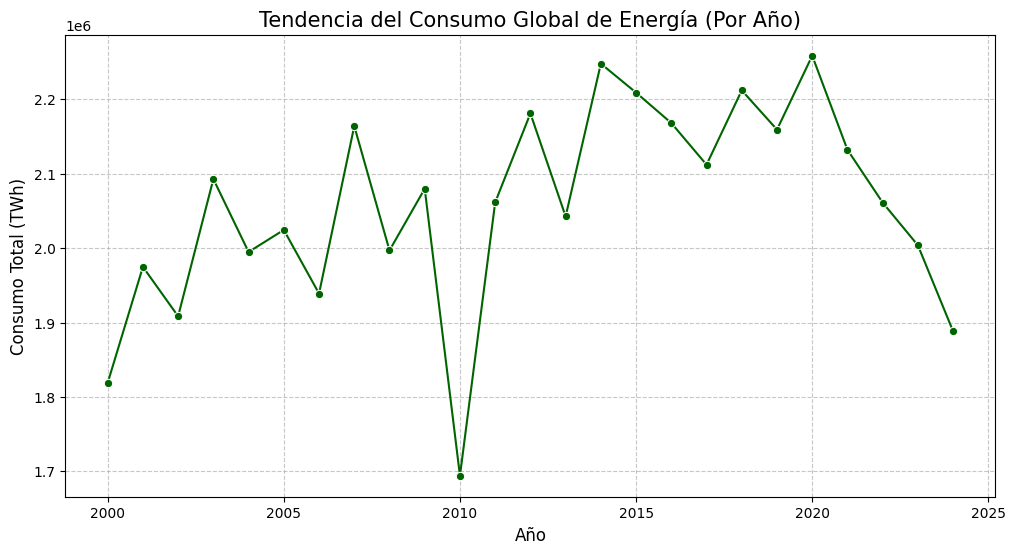

In [8]:
consumo_anual = df.groupby('Year')['Total Energy Consumption (TWh)'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=consumo_anual, x='Year', y='Total Energy Consumption (TWh)', marker='o', color='darkgreen')

plt.title('Tendencia del Consumo Global de Energía (Por Año)', fontsize=15)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Consumo Total (TWh)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

In [11]:

media = df['Total Energy Consumption (TWh)'].mean()
desviacion = df['Total Energy Consumption (TWh)'].std()

df['z_score'] = (df['Total Energy Consumption (TWh)'] - media) / desviacion

outliers = df[df['z_score'].abs() > 3]

print(f"Se encontraron {len(outliers)} registros atípicos en el consumo de energía.")

Se encontraron 0 registros atípicos en el consumo de energía.


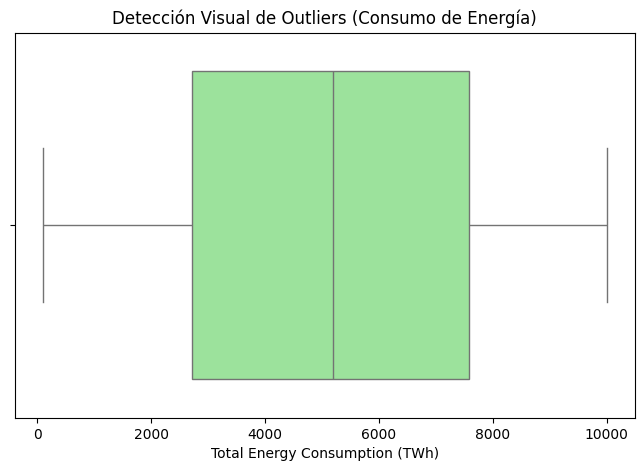

In [12]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Total Energy Consumption (TWh)'], color='lightgreen')
plt.title('Detección Visual de Outliers (Consumo de Energía)')
plt.show()

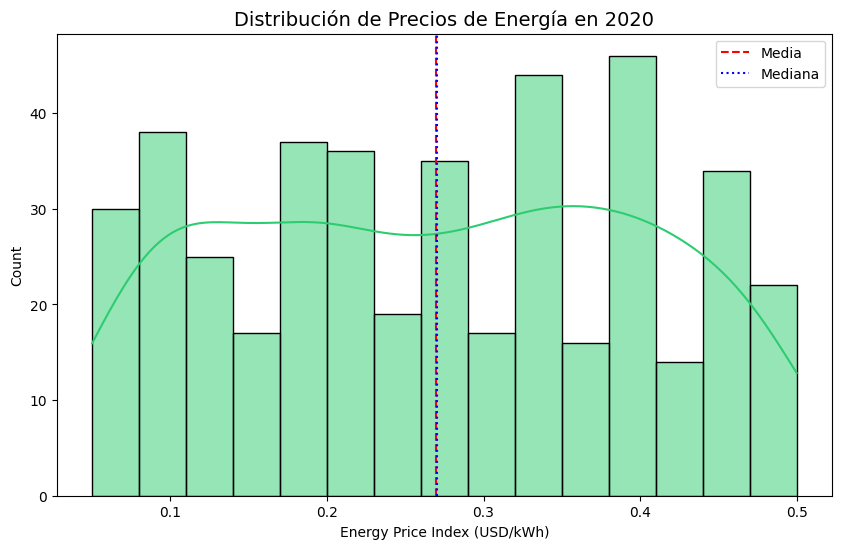

In [14]:
df_2020 = df[df['Year'] == 2020]

plt.figure(figsize=(10, 6))
sns.histplot(df_2020['Energy Price Index (USD/kWh)'], kde=True, color='#2ecc71', bins=15)

plt.axvline(df_2020['Energy Price Index (USD/kWh)'].mean(), color='red', linestyle='--', label='Media')
plt.axvline(df_2020['Energy Price Index (USD/kWh)'].median(), color='blue', linestyle=':', label='Mediana')

plt.title('Distribución de Precios de Energía en 2020', fontsize=14)
plt.legend()
plt.show()

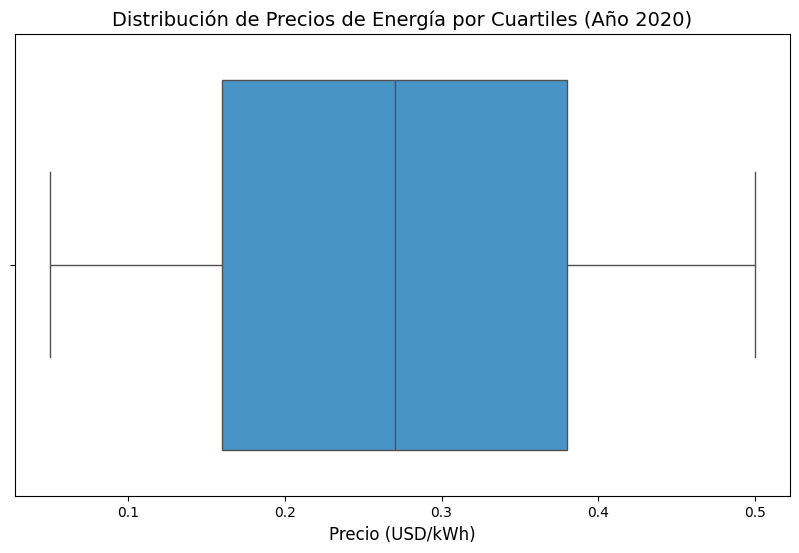

In [15]:
plt.figure(figsize=(10, 6))

sns.boxplot(x=df_2020['Energy Price Index (USD/kWh)'], color='#3498db', fliersize=5)

plt.title('Distribución de Precios de Energía por Cuartiles (Año 2020)', fontsize=14)
plt.xlabel('Precio (USD/kWh)', fontsize=12)

plt.show()

Conclusiones:

Tras realizar una inspección profunda mediante los métodos df.info() y df.describe(), se validó que el dataset está óptimamente estructurado.

No se detectaron valores nulos en las variables críticas (Consumo y Precio), eliminando riesgos de sesgo.
Las variables clave están correctamente tipificadas como numéricas, lo que garantiza la fiabilidad de los cálculos estadísticos posteriores.
dentificar si el crecimiento es lineal o exponencial es vital para la planificación de infraestructura. Este tipo de análisis permite a los operadores de red y empresas del sector prever planes de expansión y gestionar la capacidad de generación de manera eficiente.
A pesar de las asimetrías regionales esperadas, la mayoría de los mercados operan dentro de un rango de precios estándar.
La ausencia de outliers extremos en el análisis final sugiere una tendencia hacia la estabilización de costos operativos a largo plazo, reduciendo la incertidumbre para la inversión en proyectos energéticos transnacionales.